In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [3]:
from config import dir_config
from src.utils import pmf_utils, classification_utils

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)


In [4]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(processed_metadata)

PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


In [5]:
def new_accumulators():
    """Empty accumulators for positive-prior and equal-prior psychometric data."""
    return {k: {"coh": [], "psych": [], "model": [], "x_hat": [], "y_hat": []} for k in ("pos", "eq")}


def collect_psych(data, accum):
    """Fit psychometric data for both color conditions and append to accum."""
    for key, color_val in [("pos", 1), ("eq", 0)]:
        coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(data[data["color"] == color_val])
        for field, val in zip(["coh", "psych", "model", "x_hat", "y_hat"], [coh, psych, model, x_hat, y_hat]):
            accum[key][field].append(val)


def plot_mean_psych(ax, accum, pos_color, eq_color, err_style):
    """Plot group-mean psychometric curve with error bars and fitted line."""
    for key, color, label in [("pos", pos_color, "Positive Prior"), ("eq", eq_color, "Equal Prior")]:
        coh_arr = np.array(accum[key]["coh"])
        psych_arr = np.array(accum[key]["psych"])
        x_hat_arr = np.array(accum[key]["x_hat"])
        mean_coh, mean_psych = np.mean(coh_arr, axis=0), np.mean(psych_arr, axis=0)
        mean_x_hat = np.mean(x_hat_arr, axis=0)
        ax.plot(mean_coh, mean_psych, color=color, ls="", marker="o", ms=12, mec="k", label=label)
        ax.errorbar(mean_coh, mean_psych, yerr=stats.sem(psych_arr, axis=0), color=color, ls="", marker="o", ms=12, mec="k", **err_style)
        fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type="logit_4")
        ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls="-", lw=4)


In [6]:
psych_columns = [
    "positive_psych_alpha",
    "positive_psych_beta",
    "equal_psych_alpha",
    "equal_psych_beta",
    "positive_bias",
    "equal_bias",
]

psych_params = processed_metadata[psych_columns]


In [7]:
from src.utils.stats_utils import wilcoxon_battery

pos_color, eq_color = "#C2B39F", "#8C5A96"
alpha = 0.08
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}


def panel_bias_rows(grp, sub_ids=None):
    """Psych params for `grp`, restricted to `sub_ids` (the subjects a panel actually draws)."""
    idx = pd.Index(grp_indices[grp])
    if sub_ids is not None:
        idx = idx[processed_metadata.loc[idx, "subject_id"].isin(list(sub_ids))]
    return psych_params.loc[idx]


def bias_significance(panels):
    """Bonferroni-corrected p-value (positive vs equal bias) per panel, jointly across `panels`.

    Items are panel dicts (keyed by "title", so two panels sharing a group but drawing
    different subject subsets each get their own test) or a bare group name.
    """
    tests = {}
    for panel in panels:
        if isinstance(panel, str):
            key, group_data = panel, panel_bias_rows(panel)
        else:
            key, group_data = panel["title"], panel_bias_rows(panel["grp"], panel["sub_ids"])
        tests[key] = (group_data["positive_bias"], group_data["equal_bias"])
    return wilcoxon_battery(tests=tests, print_results=False).set_index("test")["corrected_p"]


def plot_curve_bias_panel(ax, sub_ids, med, grp, title, letter, p_value, inset_ylim):
    """Plot one psychometric-curve panel, with a bottom-right inset bias bar chart, onto `ax`."""
    # ── curves ──
    accum = new_accumulators()
    for sid in sub_ids:
        subj_data = filtered_data[filtered_data["subject_id"] == sid]
        if med is not None:
            subj_data = subj_data[subj_data["medication"] == med]
        if subj_data.empty:
            continue
        collect_psych(subj_data, accum)

    for key, color in [("pos", pos_color), ("eq", eq_color)]:
        for coh, psych, x_hat, y_hat in zip(accum[key]["coh"], accum[key]["psych"], accum[key]["x_hat"], accum[key]["y_hat"]):
            ax.plot(coh, psych, color=color, marker="o", ls="", alpha=alpha)
            ax.plot(x_hat, y_hat, color=color, ls="-", alpha=alpha)

    plot_mean_psych(ax, accum, pos_color, eq_color, err_style)

    ax.axhline(0.5, color="0.6", ls="--", lw=1.5, zorder=0)
    ax.axvline(0, color="0.6", ls="--", lw=1.5, zorder=0)

    # ── inset bias bar chart (bottom-right, clear of the curve) ──
    inset_rect = [0.68, 0.06, 0.28, 0.30]
    bg_rect = plt.Rectangle(
        (inset_rect[0], inset_rect[1]),
        inset_rect[2],
        inset_rect[3],
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="none",
        zorder=4,
    )
    ax.add_patch(bg_rect)
    ax_ins = ax.inset_axes(inset_rect)
    ax_ins.set_zorder(5)

    group_data = panel_bias_rows(grp, sub_ids)
    eq_vals = (group_data["equal_bias"] - 0.5).values
    pos_vals = (group_data["positive_bias"] - 0.5).values

    bar_tops = []
    for xi, (vals, color) in enumerate([(eq_vals, eq_color), (pos_vals, pos_color)]):
        mean, sem = np.mean(vals), stats.sem(vals)
        ax_ins.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6)
        ax_ins.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=4, elinewidth=1.2, capthick=1.2)
        bar_tops.append(mean + sem)

    if p_value < 0.05:
        star = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*"
        ax_ins.text(0.5, max(bar_tops) + 0.015, star, ha="center", va="bottom", fontsize=16, fontweight="bold")

    ax_ins.set_xticks([])
    ax_ins.set_ylim(*inset_ylim)
    ax_ins.set_ylabel("Bias", fontsize=14)
    ax_ins.tick_params(labelsize=10)
    for sp in ["top", "right"]:
        ax_ins.spines[sp].set_visible(False)

    # ── panel styling ──
    ax.set_xticks([-100, -35, -13, 0, 13, 35, 100])
    ax.tick_params(labelsize=15)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.set_xlim(-105, 105)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Orientation Strength (% Coherence)", fontsize=18)
    ax.text(0.03, 0.94, f"N = {len(sub_ids)}", transform=ax.transAxes, fontsize=18, va="top")
    ax.set_title(rf"$\mathbf{{{letter}}}$   {title}", loc="left", fontsize=18)


## Combined psychometric + bias summary figure

In [8]:
subjects_map


{'healthy': array(['HC1', 'HC3', 'HC6', 'HC7', 'HC8', 'HC9', 'HC12', 'HC13', 'AV',
        'BC', 'BF', 'EM', 'ES', 'GF', 'GP', 'JA', 'MRM', 'SY'],
       dtype=object),
 'all': array(['P1', 'P3', 'P4', 'P6', 'P7', 'P9', 'P11', 'P12', 'P13', 'P17',
        'P18', 'P19', 'P20', 'P22', 'P23', 'P24', 'P28', 'P29', 'P31',
        'P32', 'P33', 'P34', 'CG', 'COH', 'MBY', 'DP', 'FUR', 'LBR', 'MAR',
        'SMI', 'PAM', 'RW', 'BBK', 'BER', 'DCAM', 'ALE', 'DMO', 'RBA',
        'RDE', 'SGA', 'LHO'], dtype=object),
 'tremor_dominant': array(['P3', 'P6', 'P7', 'P11', 'P12', 'P17', 'P18', 'P19', 'P29', 'P31',
        'P32'], dtype=object),
 'bradykinesia_dominant': array(['P1', 'P4', 'P9', 'P13', 'P20', 'P22', 'P23', 'P28', 'P33', 'P34'],
       dtype=object)}

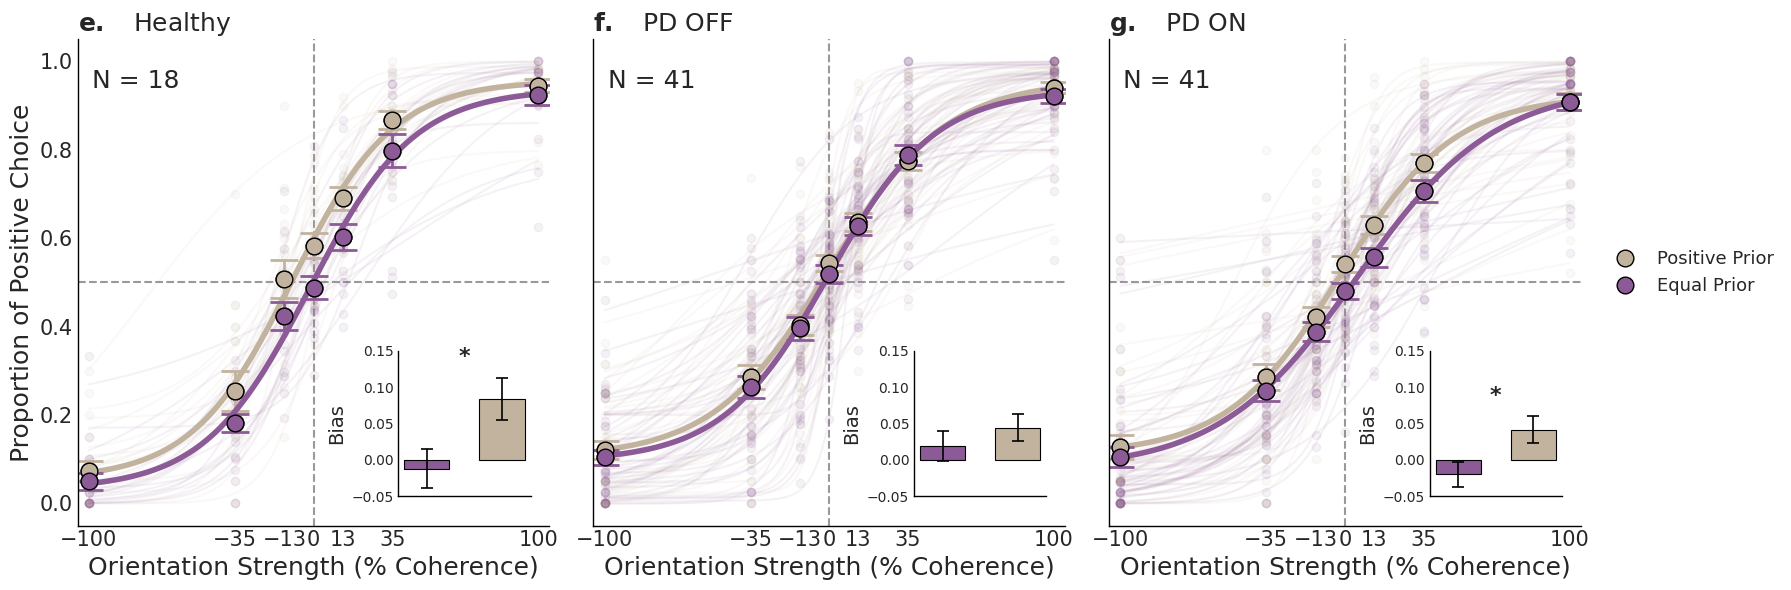

In [9]:
main_panels = [
    {"grp": "healthy", "sub_ids": subjects_map["healthy"], "med": None, "title": "Healthy"},
    {"grp": "pd_off", "sub_ids": subjects_map["all"], "med": "off", "title": "PD OFF"},
    {"grp": "pd_on", "sub_ids": subjects_map["all"], "med": "on", "title": "PD ON"},
]
main_letters = ["e.", "f.", "g."]
main_corrected_p = bias_significance(main_panels)

fig, axes = plt.subplots(1, len(main_panels), figsize=(18, 6), sharey=True)
for ax, panel, letter in zip(axes, main_panels, main_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        main_corrected_p[panel["title"]],
        inset_ylim=(-0.05, 0.15),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 0.60), fontsize=13, frameon=False)
fig.tight_layout()


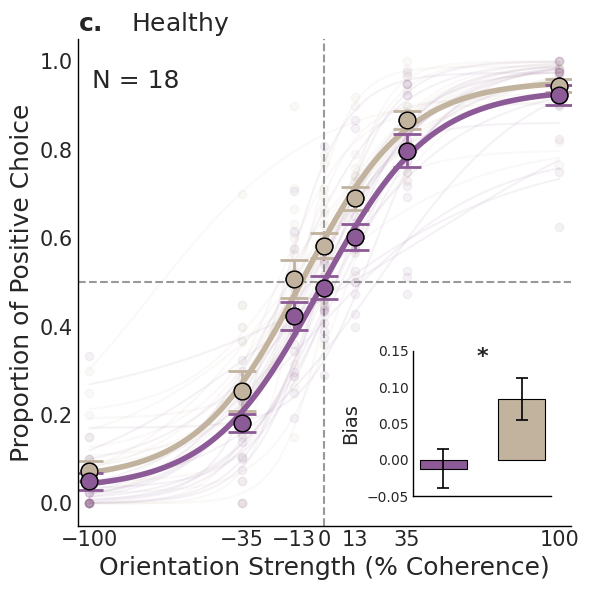

In [10]:
main_panels = {"grp": "healthy", "sub_ids": subjects_map["healthy"], "med": None, "title": "Healthy"}

main_letters = "c."
main_corrected_p = bias_significance([main_panels])

fig, axes = plt.subplots(1, 1, figsize=(6, 6), sharey=True)
axes = [axes]
# for ax, panel, letter in zip(axes, main_panels, main_letters):
plot_curve_bias_panel(
    axes[0],
    main_panels["sub_ids"],
    main_panels["med"],
    main_panels["grp"],
    main_panels["title"],
    main_letters,
    main_corrected_p[main_panels["title"]],
    inset_ylim=(-0.05, 0.15),
)

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
# axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 0.60), fontsize=13, frameon=False)
fig.tight_layout()


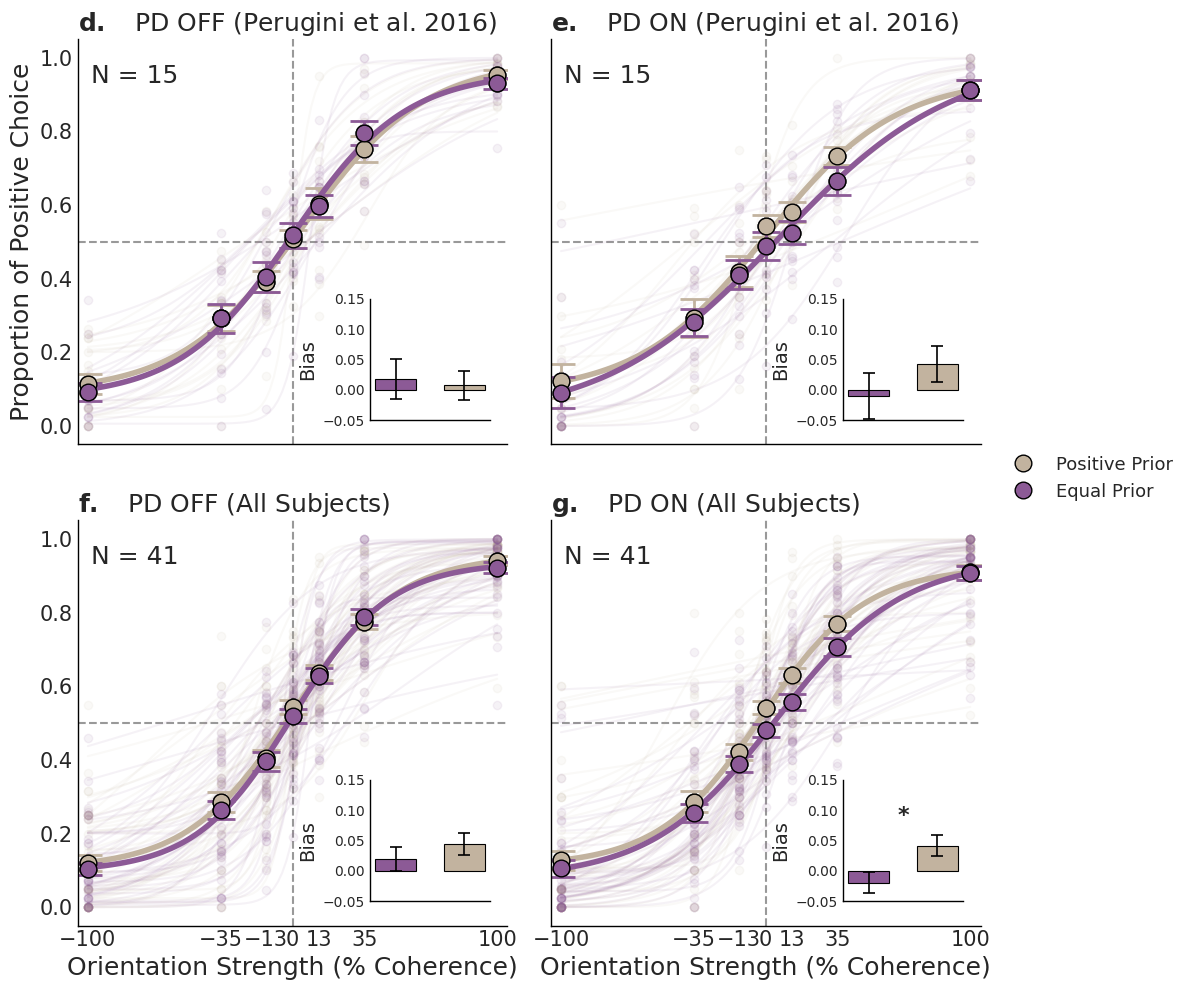

In [11]:
ucla_pd = set(processed_metadata[(processed_metadata["experiment_site"] == "UCLA") & (processed_metadata["is_pd"] == 1)]["subject_id"].unique())


main_panels = [
    {"grp": "pd_off", "sub_ids": ucla_pd, "med": "off", "title": "PD OFF (Perugini et al. 2016)"},
    {"grp": "pd_on", "sub_ids": ucla_pd, "med": "on", "title": "PD ON (Perugini et al. 2016)"},
    {"grp": "pd_off", "sub_ids": subjects_map["all"], "med": "off", "title": "PD OFF (All Subjects)"},
    {"grp": "pd_on", "sub_ids": subjects_map["all"], "med": "on", "title": "PD ON (All Subjects)"},
]
main_letters = ["d.", "e.", "f.", "g."]
main_corrected_p = bias_significance(main_panels)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()
for ax, panel, letter in zip(axes, main_panels, main_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        main_corrected_p[panel["title"]],
        inset_ylim=(-0.05, 0.15),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
for i in [0, 1]:
    axes[i].set_xticklabels([])
    axes[i].set_xlabel("")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.2), fontsize=13, frameon=False)
fig.tight_layout()


## Combined psychometric + bias summary figure — Tremor vs Bradykinesia subtypes

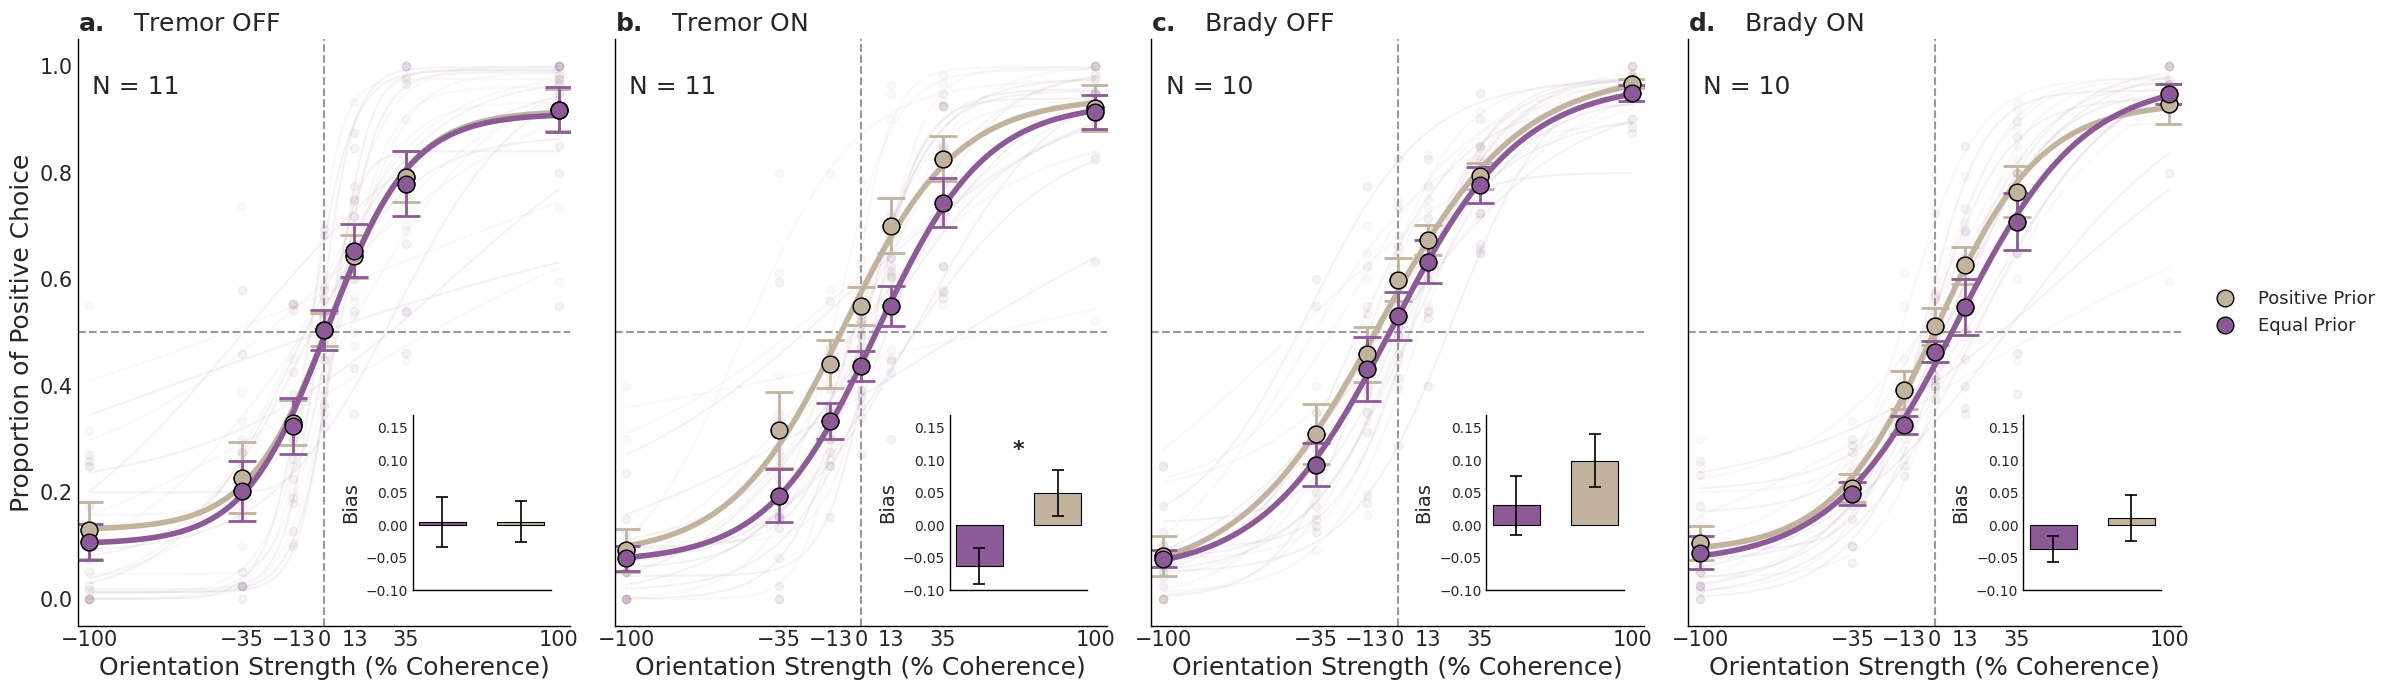

In [12]:
subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "c.", "d."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axes = plt.subplots(1, len(subtype_panels), figsize=(24, 7), sharey=True)
for ax, panel, letter in zip(axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 0.60), fontsize=13, frameon=False)
fig.tight_layout()


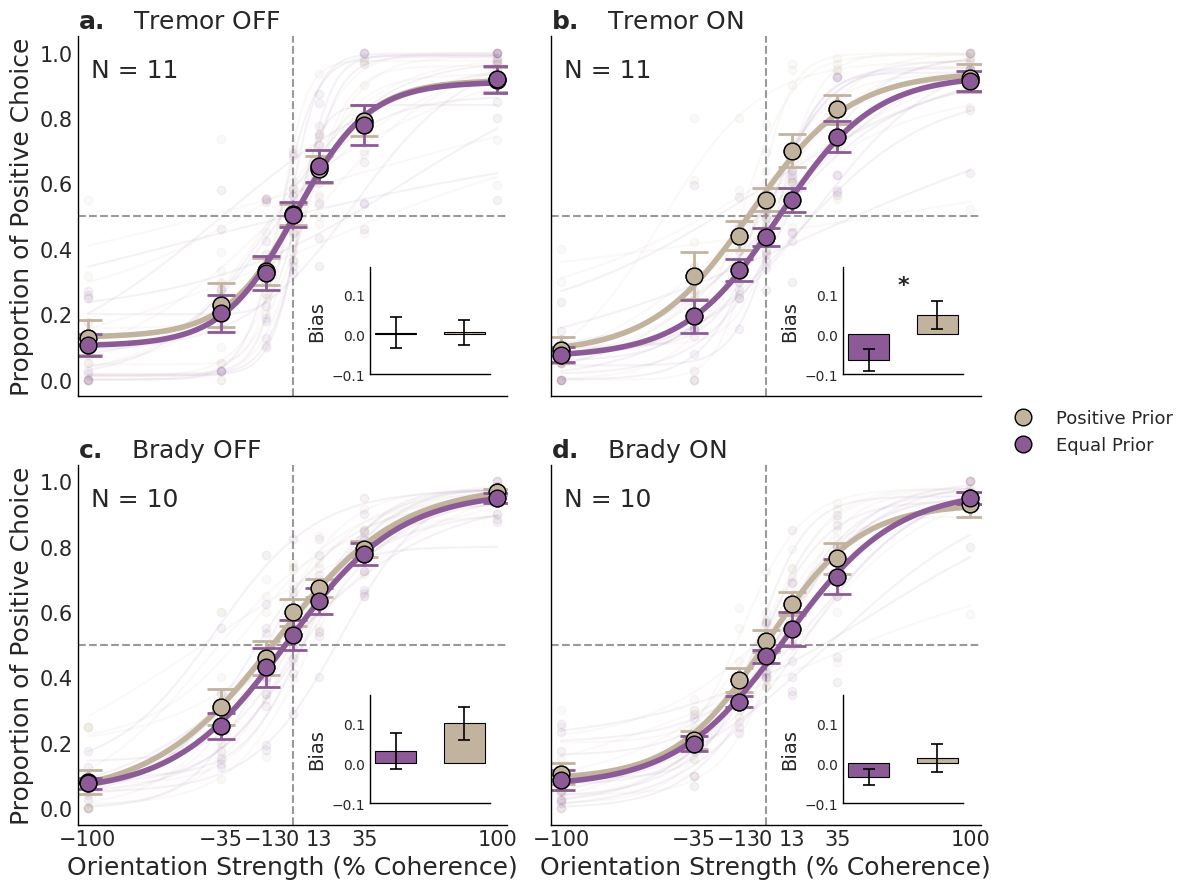

In [13]:
subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "c.", "d."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()
for ax, panel, letter in zip(axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
axes[2].set_ylabel("Proportion of Positive Choice", fontsize=18)
for i in [0,1]:
    axes[i].set_xticklabels([])
    axes[i].set_xlabel("")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.2), fontsize=13, frameon=False)
fig.tight_layout()


# Trial-level hierarchical model (MCMC)

The published panel fit this model by mean-field variational inference. `2.25-posterior-interaction-with-mcmc`
shows that approximation rejects a true null in ~52% of datasets with no medication effect and that its
posterior is about three times too narrow, so its p-values cannot be reported. The same model is fit here
with NUTS, and the interaction is shown as a full posterior rather than an asterisk.

In [14]:
from scipy import stats as scipy_stats

# Subject-level DiD scores (positive-vs-equal bias, ON minus OFF), needed by the trial-level
# comparison below. Computed silently here — the DiD figures themselves live in 2.20.
did_group_order = ["tremor", "brady"]
did_group_titles = {"tremor": "Tremor Dominant", "brady": "Brady Dominant"}

did_results = {}
for grp in did_group_order:
    off_idx, on_idx = grp_indices[f"{grp}_off"], grp_indices[f"{grp}_on"]
    prior_effect_off = psych_params.loc[off_idx, "positive_bias"].to_numpy() - psych_params.loc[off_idx, "equal_bias"].to_numpy()
    prior_effect_on = psych_params.loc[on_idx, "positive_bias"].to_numpy() - psych_params.loc[on_idx, "equal_bias"].to_numpy()
    did_results[("bias", grp)] = prior_effect_on - prior_effect_off


In [15]:
from src.utils.mcmc_cache import FIT_SETTINGS, TERMS, fit_or_load, loso_or_load, prepare_trials

# The model, the sampler settings and the seed live in src/utils/mcmc_cache.py and are shared with
# 2.25, so both notebooks report the same posterior. Colour and medication are effect-coded at
# +/- 0.5, making `col:med` the trial-level analogue of the subject-level difference-in-differences
# contrast; previous-trial terms are carried as covariates so sequential effects cannot load onto it.
# The first run samples (~2-3 min) and caches the draws; every later run loads them back.
mcmc_group_subjects = {
    "tremor": subjects_map["tremor_dominant"],
    "brady": subjects_map["bradykinesia_dominant"],
}
mcmc_group_titles = {"tremor": "Tremor Dominant", "brady": "Bradykinesia Dominant"}

mcmc_subsets = {grp: prepare_trials(filtered_data, subs) for grp, subs in mcmc_group_subjects.items()}
mcmc_fits = {grp: fit_or_load(grp, subset) for grp, subset in mcmc_subsets.items()}
mcmc_posterior = {grp: fit.draws for grp, fit in mcmc_fits.items()}

print(f"sampler settings: {FIT_SETTINGS}")
print({grp: draws.shape for grp, draws in mcmc_posterior.items()})

tremor: loaded cached draws (seed 0, fingerprint 83343e2a0808003c)
bradykinetic: loaded cached draws (seed 0, fingerprint 09c20dc9793f9f03)
sampler settings: {'draws': 1000, 'tune': 1000, 'chains': 4, 'target_accept': 0.9, 'seed': 0}
{'tremor': (4000, 7), 'brady': (4000, 7)}


### Convergence diagnostics

Report these in the manuscript. A hierarchical model on ~11 subjects is exactly the setting where
sampling problems appear, so silence about diagnostics invites the question.

In [16]:
mcmc_diagnostics = pd.DataFrame(
    [
        {
            "group": mcmc_group_titles[grp],
            "subjects": fit.n_subjects,
            "trials": fit.n_trials,
            "divergences": fit.divergences,
            "max r_hat": fit.rhat.max(),
            "min ESS (bulk)": fit.ess_bulk.min(),
        }
        for grp, fit in mcmc_fits.items()
    ]
).set_index("group")
mcmc_diagnostics.round(4)

,subjects,trials,divergences,max r_hat,min ESS (bulk)
group,,,,,
Tremor Dominant,11,13518,0,1.0057,906.4227
Bradykinesia Dominant,10,12529,0,1.0054,1238.9465


### Posterior summary for all population-level effects

In [17]:
summary_rows = []
for grp, samples in mcmc_posterior.items():
    for i, term in enumerate(TERMS):
        draws = samples[:, i]
        low, high = np.percentile(draws, [2.5, 97.5])
        summary_rows.append(
            {
                "group": mcmc_group_titles[grp],
                "term": term,
                "mean": draws.mean(),
                "SD": draws.std(),
                "2.5%": low,
                "97.5%": high,
                "P(effect > 0)": (draws > 0).mean(),
            }
        )

posterior_summary = pd.DataFrame(summary_rows).set_index(["group", "term"])
posterior_summary.round(4)

mean      SD    2.5%   97.5%  \
group                 term                                          
Tremor Dominant       intercept    0.0111  0.1005 -0.1845  0.2118   
                      coh          3.5019  0.5640  2.3705  4.6032   
                      col          0.3347  0.1247  0.0800  0.5761   
                      med          0.0538  0.1280 -0.2046  0.3100   
                      col:med      0.5311  0.2774 -0.0152  1.0877   
                      prev_rc      0.1776  0.0968 -0.0134  0.3740   
                      prev_rc:med -0.1111  0.1014 -0.3219  0.0932   
Bradykinesia Dominant intercept    0.0537  0.0804 -0.1010  0.2130   
                      coh          3.0737  0.2487  2.5871  3.5627   
                      col          0.2320  0.1414 -0.0445  0.5070   
                      med         -0.2953  0.2205 -0.7374  0.1412   
                      col:med      0.0370  0.2822 -0.5366  0.5785   
                      prev_rc      0.2134  0.0298  0.1538  0.2724   
                      prev_rc:med -0.0031  0.0852 -0.1783  0.1630   

                                   P(effect > 0)  
group                 term                        
Tremor Dominant       intercept           0.5410  
                      coh                 1.0000  
                      col                 0.9932  
                      med                 0.6642  
                      col:med             0.9700  
                      prev_rc             0.9695  
                      prev_rc:med         0.1172  
Bradykinesia Dominant intercept           0.7610  
                      coh                 1.0000  
                      col                 0.9570  
                      med                 0.0788  
                      col:med             0.5550  
                      prev_rc             1.0000  
                      prev_rc:med         0.4838

### Subject-level DiD vs. trial-level interaction

In [18]:
comparison_rows = []
for grp in did_group_order:
    wilcoxon_p = scipy_stats.wilcoxon(did_results[("bias", grp)]).pvalue
    draws = mcmc_posterior[grp][:, TERMS.index("col:med")]
    low, high = np.percentile(draws, [2.5, 97.5])
    comparison_rows.append(
        {
            "group": mcmc_group_titles[grp],
            "n_subjects": mcmc_subsets[grp]["subject_id"].nunique(),
            "n_trials": len(mcmc_subsets[grp]),
            "wilcoxon_DiD_p (subject-level)": wilcoxon_p,
            "interaction mean (trial-level)": draws.mean(),
            "95% CI": f"[{low:+.2f}, {high:+.2f}]",
            "P(interaction > 0)": (draws > 0).mean(),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("group")
comparison_df.round(4)

,n_subjects,n_trials,wilcoxon_DiD_p (subject-level),interaction mean (trial-level),95% CI,P(interaction > 0)
group,,,,,,
Tremor Dominant,11,13518,0.1475,0.5311,"[-0.02, +1.09]",0.970
Bradykinesia Dominant,10,12529,0.8457,0.0370,"[-0.54, +0.58]",0.555


## Combined figure — psychometric curves and trial-level posterior

Panels e,f give the model-predicted bias OFF versus ON with 95% credible intervals and each subject's
observed zero-coherence choice proportion behind them; panels g,h show the posterior of the
colour x medication interaction itself, so the evidence is visible rather than inferred from whether
intervals overlap.

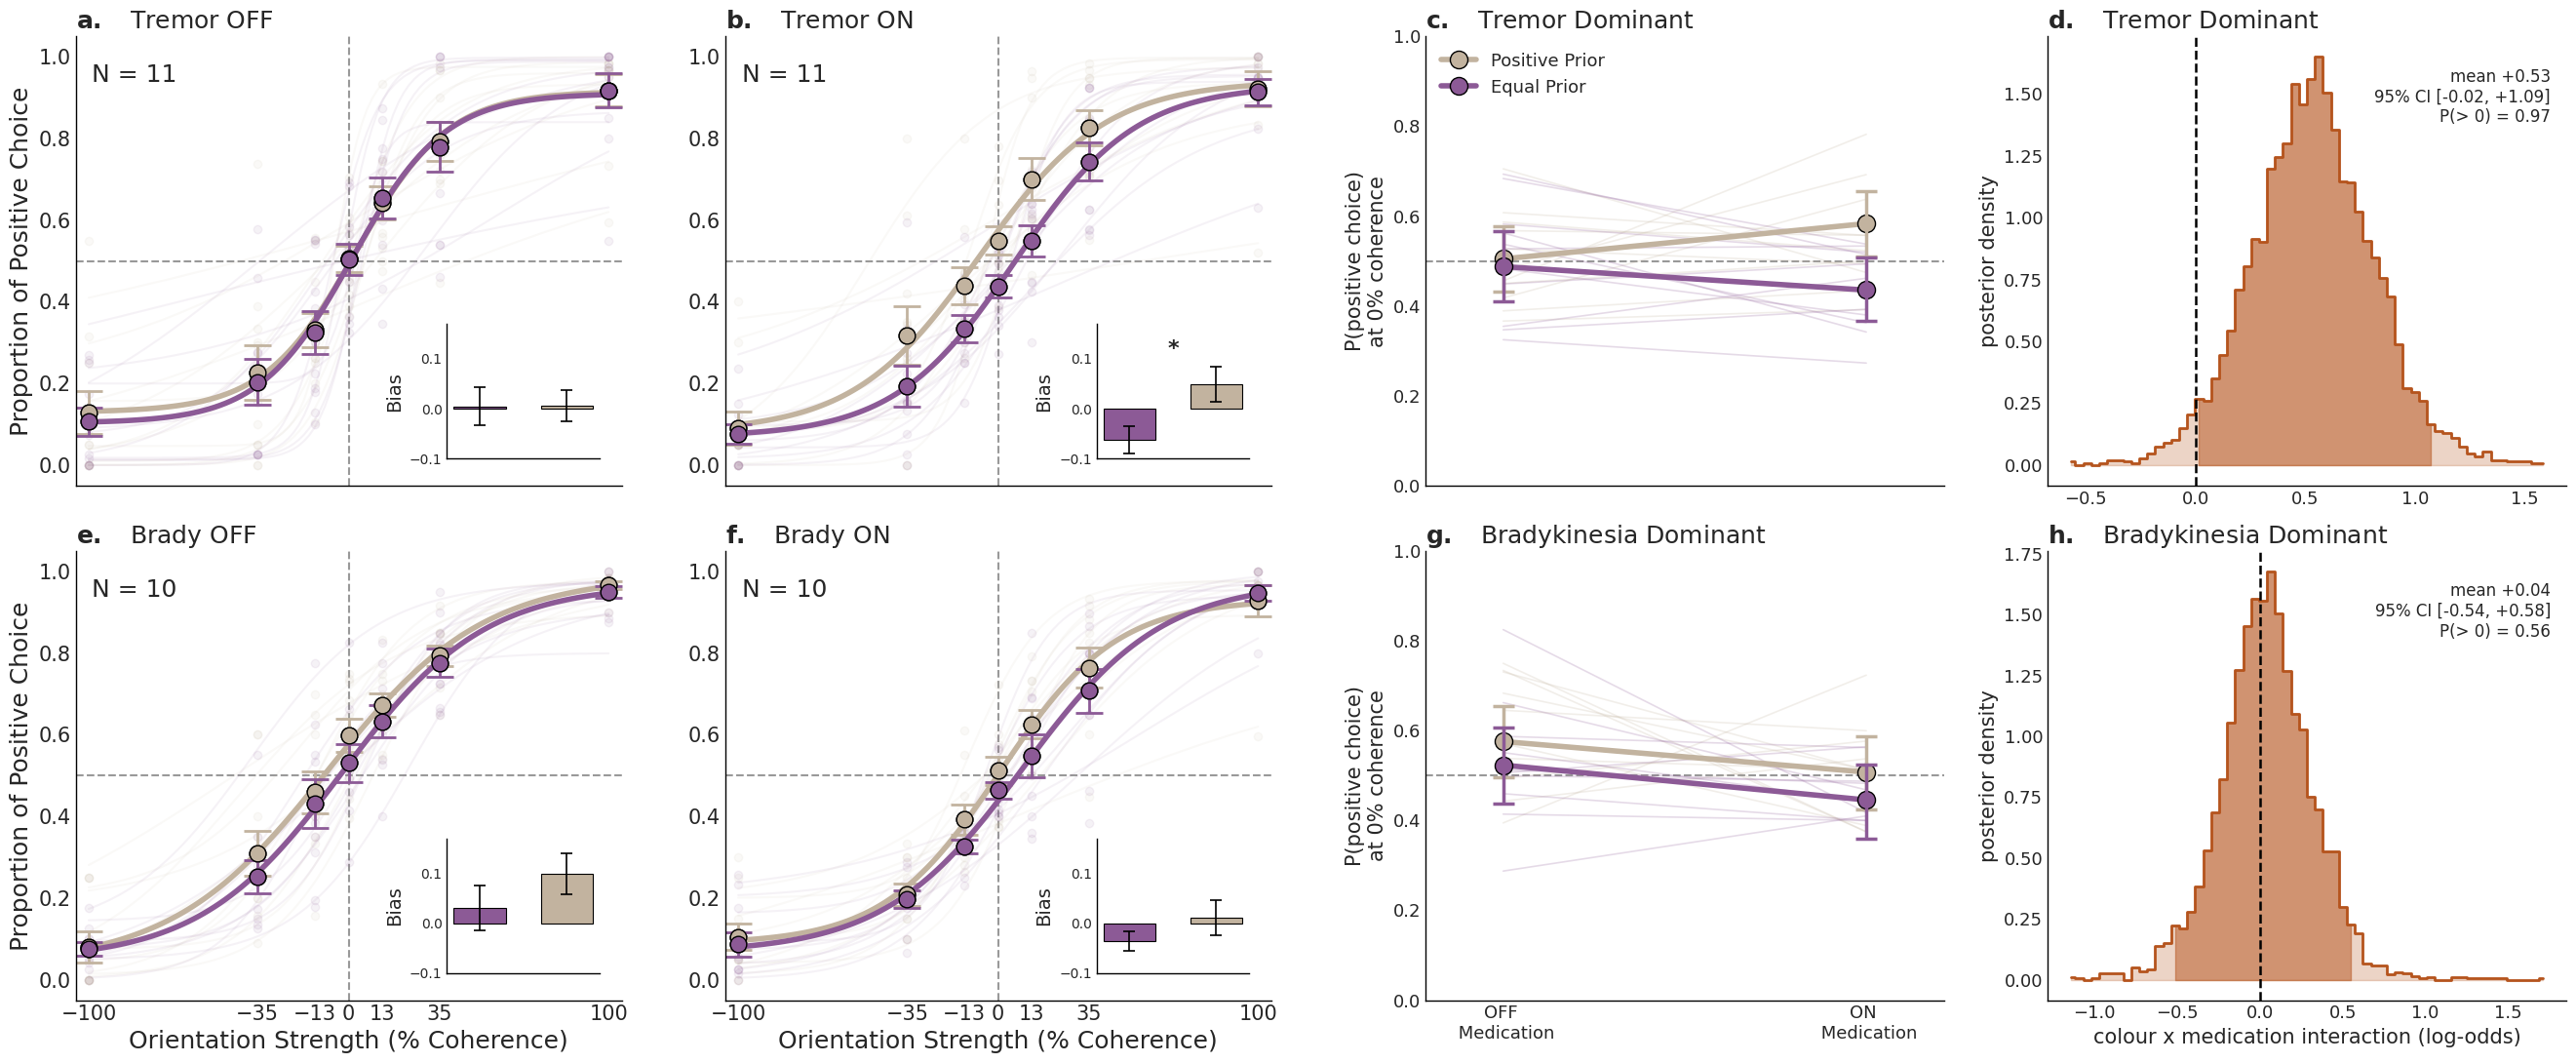

In [19]:
POSTERIOR_COLOR = "#B5541D"
mcmc_err_style = {"elinewidth": 2.5, "capsize": 8, "capthick": 2.5}


def predicted_probability(samples, colour, medication):
    """Posterior of P(positive choice) at 0% coherence and neutral trial history."""
    eta = (
        samples[:, TERMS.index("intercept")]
        + colour * samples[:, TERMS.index("col")]
        + medication * samples[:, TERMS.index("med")]
        + colour * medication * samples[:, TERMS.index("col:med")]
    )
    return 1 / (1 + np.exp(-eta))


def observed_bias(subset):
    """Each subject's observed choice proportion at 0% coherence, per condition."""
    zero = subset[subset["coherence"] == 0]
    return zero.groupby(["subject_id", "med", "col"])["choice"].mean()


subtype_panels = [
    {"grp": "tremor_off", "sub_ids": subjects_map["tremor_dominant"], "med": "off", "title": "Tremor OFF"},
    {"grp": "tremor_on", "sub_ids": subjects_map["tremor_dominant"], "med": "on", "title": "Tremor ON"},
    {"grp": "brady_off", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "off", "title": "Brady OFF"},
    {"grp": "brady_on", "sub_ids": subjects_map["bradykinesia_dominant"], "med": "on", "title": "Brady ON"},
]
subtype_letters = ["a.", "b.", "e.", "f."]
subtype_corrected_p = bias_significance(subtype_panels)

fig, axs = plt.subplots(2, 4, figsize=(26, 11), gridspec_kw={"width_ratios": [1, 1, 0.95, 0.95]})
curve_axes = [axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]]
pred_axes = {"tremor": axs[0, 2], "brady": axs[1, 2]}
post_axes = {"tremor": axs[0, 3], "brady": axs[1, 3]}
pred_letters = {"tremor": "c.", "brady": "g."}
post_letters = {"tremor": "d.", "brady": "h."}

# ── a–d: psychometric curves with bias insets ──
for ax, panel, letter in zip(curve_axes, subtype_panels, subtype_letters):
    plot_curve_bias_panel(
        ax,
        panel["sub_ids"],
        panel["med"],
        panel["grp"],
        panel["title"],
        letter,
        subtype_corrected_p[panel["title"]],
        inset_ylim=(-0.10, 0.17),
    )

curve_axes[0].set_ylabel("Proportion of Positive Choice", fontsize=18)
curve_axes[2].set_ylabel("Proportion of Positive Choice", fontsize=18)
for ax in curve_axes[:2]:
    ax.set_xticklabels([])
    ax.set_xlabel("")

# ── e,f: model-predicted bias OFF vs ON ──
x = np.array([0.15, 0.85])
for grp in did_group_order:
    ax = pred_axes[grp]
    samples, subset = mcmc_posterior[grp], mcmc_subsets[grp]
    observed = observed_bias(subset)

    for colour_value, color, label in [(0.5, pos_color, "Positive Prior"), (-0.5, eq_color, "Equal Prior")]:
        means, lows, highs = [], [], []
        for medication in (-0.5, 0.5):
            draws = predicted_probability(samples, colour_value, medication)
            low, high = np.percentile(draws, [2.5, 97.5])
            means.append(draws.mean())
            lows.append(low)
            highs.append(high)
        means, lows, highs = np.array(means), np.array(lows), np.array(highs)
        ax.plot(x, means, "-o", color=color, ms=13, mec="k", lw=4, zorder=4, label=label)
        ax.errorbar(x, means, yerr=[means - lows, highs - means], color=color, ls="", zorder=4, **mcmc_err_style)
        for subject in subset["subject_id"].unique():
            try:
                pair = [observed.loc[(subject, m, colour_value)] for m in (-0.5, 0.5)]
            except KeyError:
                continue
            ax.plot(x, pair, color=color, alpha=0.22, lw=1.2, zorder=2)

    ax.axhline(0.5, color="0.6", ls="--", lw=1.5, zorder=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(["OFF \n Medication", "ON \n Medication"] if grp == "brady" else [], fontsize=16)
    ax.set_ylabel("P(positive choice)\nat 0% coherence", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.set_title(rf"$\mathbf{{{pred_letters[grp]}}}$   {mcmc_group_titles[grp]}", loc="left", fontsize=18)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

# ── g,h: posterior of the colour x medication interaction ──
for grp in did_group_order:
    ax = post_axes[grp]
    draws = mcmc_posterior[grp][:, TERMS.index("col:med")]
    low, high = np.percentile(draws, [2.5, 97.5])
    counts, edges = np.histogram(draws, bins=60, density=True)
    centres = (edges[:-1] + edges[1:]) / 2
    inside = (centres >= low) & (centres <= high)

    ax.fill_between(centres, counts, color=POSTERIOR_COLOR, alpha=0.25, step="mid")
    ax.fill_between(centres[inside], counts[inside], color=POSTERIOR_COLOR, alpha=0.5, step="mid")
    ax.plot(centres, counts, color=POSTERIOR_COLOR, lw=2, drawstyle="steps-mid")
    ax.axvline(0, color="k", ls="--", lw=1.8)
    ax.annotate(
        f"mean {draws.mean():+.2f}\n95% CI [{low:+.2f}, {high:+.2f}]\nP(> 0) = {(draws > 0).mean():.2f}",
        (0.97, 0.93),
        xycoords="axes fraction",
        ha="right",
        va="top",
        fontsize=12,
    )
    if grp == "brady":
        ax.set_xlabel("colour x medication interaction (log-odds)", fontsize=15)
    ax.set_ylabel("posterior density", fontsize=15)
    ax.tick_params(labelsize=13)
    ax.set_title(rf"$\mathbf{{{post_letters[grp]}}}$   {mcmc_group_titles[grp]}", loc="left", fontsize=18)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

pred_axes["tremor"].legend(loc="upper left", fontsize=13, frameon=False)
fig.tight_layout()

# nudge the model columns right for a bit of visual separation from the curve panels
column_gap = 0.02
for ax in list(pred_axes.values()) + list(post_axes.values()):
    pos = ax.get_position()
    ax.set_position([pos.x0 + column_gap, pos.y0, pos.width, pos.height])

### Leave-one-subject-out sensitivity check

With a posterior rather than a p-value the useful summary is not how many refits cross a threshold but
how stable the estimate is: does the posterior mean move much, does the sign flip, does P(> 0) hold up.
Refits use 500 draws per chain, which is ample for a mean and a tail probability.

**Long-running: ~21 refits at roughly 80 s each, about half an hour.**

In [20]:
# Cached per subtype: the first run does ~21 refits at roughly 80 s each, later runs read the table.
loso = pd.concat(
    [loso_or_load(grp, subset).assign(group=grp) for grp, subset in mcmc_subsets.items()],
    ignore_index=True,
)
loso.set_index(["group", "held_out"]).round(4)

Initializing NUTS using jitter+adapt_diag...


tremor: refitting without each of 11 subjects (~80 s each)...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 83 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 83 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 80 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 81 seconds.
The rhat statistic is larger than 1.01 

tremor: cached to processed/mcmc_fits/tremor_loso.csv
bradykinetic: refitting without each of 10 subjects (~80 s each)...


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 50 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 52 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd_u, z_u]
Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 54 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sd

bradykinetic: cached to processed/mcmc_fits/bradykinetic_loso.csv


mean      SD    2.5%   97.5%  P(> 0)  CI excludes 0  \
group  held_out                                                          
tremor P11       0.5485  0.3103 -0.0147  1.2005  0.9730          False   
       P12       0.4792  0.3221 -0.1791  1.1169  0.9315          False   
       P17       0.4222  0.2840 -0.1900  0.9710  0.9330          False   
       P18       0.5797  0.3035 -0.0431  1.1755  0.9710          False   
       P19       0.5578  0.3042 -0.0387  1.1552  0.9695          False   
       P29       0.4670  0.3121 -0.1284  1.0820  0.9395          False   
       P3        0.5196  0.3101 -0.0852  1.1054  0.9580          False   
       P31       0.7043  0.2368  0.2514  1.1967  0.9990           True   
       P32       0.5403  0.3183 -0.1229  1.1920  0.9535          False   
       P6        0.4080  0.2697 -0.1143  0.9230  0.9435          False   
       P7        0.5644  0.2956  0.0099  1.1588  0.9775           True   
brady  P1       -0.1063  0.2632 -0.6223  0.4196  0.3325          False   
       P13       0.0459  0.3218 -0.5856  0.6962  0.5655          False   
       P20       0.0100  0.3125 -0.6331  0.6280  0.5155          False   
       P22       0.1892  0.2702 -0.3587  0.7591  0.7790          False   
       P23       0.1283  0.2897 -0.4762  0.7125  0.6905          False   
       P28      -0.0236  0.3019 -0.6218  0.5953  0.4695          False   
       P33       0.0919  0.3002 -0.5343  0.6581  0.6410          False   
       P34       0.0269  0.3002 -0.5732  0.6402  0.5280          False   
       P4        0.1081  0.2895 -0.4592  0.6890  0.6640          False   
       P9       -0.0481  0.2972 -0.6163  0.5720  0.4175          False   

                 divergences  
group  held_out               
tremor P11                 0  
       P12                 0  
       P17                 0  
       P18                 0  
       P19                 0  
       P29                 0  
       P3                  0  
       P31                 0  
       P32                 0  
       P6                  0  
       P7                  0  
brady  P1                  0  
       P13                 0  
       P20                 0  
       P22                 0  
       P23                 0  
       P28                 0  
       P33                 0  
       P34                 0  
       P4                  0  
       P9                  0

In [21]:
stability_rows = []
for grp, block in loso.groupby("group"):
    full_mean = mcmc_posterior[grp][:, TERMS.index("col:med")].mean()
    stability_rows.append(
        {
            "group": mcmc_group_titles[grp],
            "full-data mean": full_mean,
            "refits": len(block),
            "mean range": f"{block['mean'].min():+.3f} to {block['mean'].max():+.3f}",
            "same sign as full": int((np.sign(block["mean"]) == np.sign(full_mean)).sum()),
            "P(> 0) range": f"{block['P(> 0)'].min():.2f} to {block['P(> 0)'].max():.2f}",
            "CI excludes 0": int(block["CI excludes 0"].sum()),
            "total divergences": int(block["divergences"].sum()),
        }
    )

pd.DataFrame(stability_rows).set_index("group")

,full-data mean,refits,mean range,same sign as full,P(> 0) range,CI excludes 0,total divergences
group,,,,,,,
Bradykinesia Dominant,0.037010,10,-0.106 to +0.189,7,0.33 to 0.78,0,0
Tremor Dominant,0.531144,11,+0.408 to +0.704,11,0.93 to 1.00,2,0


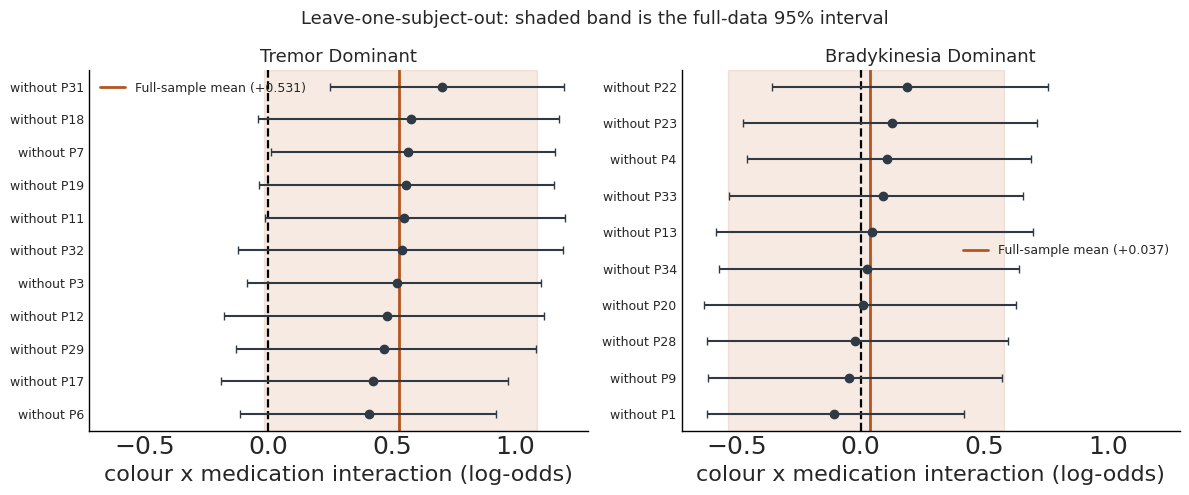

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for ax, grp in zip(axes, did_group_order):
    block = loso[loso["group"] == grp].sort_values("mean").reset_index(drop=True)
    full_draws = mcmc_posterior[grp][:, TERMS.index("col:med")]
    full_low, full_high = np.percentile(full_draws, [2.5, 97.5])

    ax.axvspan(full_low, full_high, color=POSTERIOR_COLOR, alpha=0.12, zorder=0)
    ax.axvline(full_draws.mean(), color=POSTERIOR_COLOR, lw=2, zorder=1, label=f"Full-sample mean ({full_draws.mean():+.3f})")
    ax.axvline(0, color="k", ls="--", lw=1.6, zorder=1)

    positions = np.arange(len(block))
    ax.errorbar(
        block["mean"],
        positions,
        xerr=[block["mean"] - block["2.5%"], block["97.5%"] - block["mean"]],
        ls="",
        marker="o",
        ms=6,
        color="#2F3A45",
        capsize=3,
        lw=1.5,
    )
    ax.set_yticks(positions)
    ax.set_yticklabels([f"without {s}" for s in block["held_out"]], fontsize=9)
    ax.set_xlabel("colour x medication interaction (log-odds)")
    ax.set_title(mcmc_group_titles[grp], fontsize=13)
    ax.legend(frameon=False, fontsize=9, loc="best")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

fig.suptitle("Leave-one-subject-out: shaded band is the full-data 95% interval", fontsize=13)
fig.tight_layout()
plt.show()